# Wildfire Early Warning System
### NASA Disasters Program | Lifelines Data Studio Module

---

## What This Module Does

This notebook walks you through building a wildfire early warning pipeline using free, publicly available satellite data. By the end, you will have:

- Detected active fires in your area of interest (AOI) using NASA FIRMS satellite data
- Identified infrastructure (buildings, roads, facilities) at risk within 2, 5, and 10 km of fire detections
- Estimated population exposure within each risk zone
- Analyzed land cover to understand fire spread potential
- Generated a PDF briefing and a GeoJSON package ready to load into QGIS

---

## Who This Is For

This module is designed for **humanitarian decision makers, GIS analysts, and emergency responders** who want a repeatable, near real-time pipeline for wildfire impact assessment. You do not need to be an expert programmer — each code cell is explained in plain language.

---

## Data Sources

| Dataset | Source | What it tells us |
|---|---|---|
| Active fire detections | NASA FIRMS (VIIRS NOAA-21) | Where fires are burning right now |
| Buildings & infrastructure | OpenStreetMap | What assets are at risk |
| Population | WorldPop | How many people are exposed |
| Land cover | ESA WorldCover | Fuel types and spread potential |

---

## How to Use This Notebook

1. **Run cells in order** — click each cell and press `Shift+Enter`, or use **Runtime → Run All**
2. **Only edit the Configuration cell** (Cell 3) — all your inputs go there
3. **Outputs are saved automatically** at the end — a PDF briefing and a QGIS-ready GeoJSON package

> **New to Colab?** A "cell" is a block of code or text. To run a code cell, click the ▶ play button on the left side or press `Shift+Enter`.

---
## Step 1: Install Dependencies

This cell installs the Python libraries this notebook needs. You only need to run this once per Colab session. If you close and reopen the notebook, run it again.

**Libraries we're using:**
- `geopandas` — working with geographic data (shapefiles, GeoJSON)
- `rasterio` / `rioxarray` — reading and analyzing raster files (population, land cover)
- `requests` — fetching data from the FIRMS API
- `gdown` — downloading files from Google Drive
- `matplotlib` — creating maps and charts
- `reportlab` — generating the PDF briefing

In [18]:
# Install required libraries
!pip install geopandas rasterio rioxarray requests gdown matplotlib reportlab shapely contextily --quiet
print("All libraries installed successfully")

All libraries installed successfully


---
## Step 2: Import Libraries

Now we load the libraries into memory so we can use them throughout the notebook.

In [34]:
import io, os, zipfile, warnings
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rioxarray as rxr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import gdown
from shapely.geometry import Point
from shapely.ops import unary_union
from rasterio.mask import mask as rio_mask
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER
from datetime import datetime
import contextily as cx
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


---
## Step 3: Configuration

This is the only cell you need to edit. All the inputs for your analysis are set here in one place, so you never have to dig through the code.

For this demo, everything is pre-filled and ready to run. When you adapt this for your own incident, you will update:
- The AOI file path to your own area of interest
- The FIRMS API key (free registration at [firms.modaps.eosdis.nasa.gov](https://firms.modaps.eosdis.nasa.gov/api/area/))
- Open Street Map (OSM) Buildings (Use QuickOSM Plugin in QGIS to download buildings from your AOI)
- The WorldPop and WorldCover file paths to your own downloaded rasters

### About the Data Files

For this demo, we have pre-prepared three files clipped to the AOI and stored in a shared Google Drive:

- AOI GeoJSON — a polygon defining the area of interest
- OSM Buildings Shapefile - Building and other infrastructure data. 
- WorldPop raster — gridded population estimates at ~100m resolution. Download your own from [worldpop.org](https://www.worldpop.org/)
- ESA WorldCover raster — 10m land cover classification. Download your own from [esa-worldcover.org](https://esa-worldcover.org/)

> Tip: When preparing your own data, clip both rasters to your AOI boundary before uploading to Drive. This keeps file sizes small and processing fast. You can do this in QGIS using Raster → Extraction → Clip Raster by Mask Layer.

In [ ]:
# =============================================================
#   CONFIGURATION — Edit this cell for your own incident
# =============================================================

# --- FIRMS API Key ---
# Register for a free key at: https://firms.modaps.eosdis.nasa.gov/api/area/
FIRMS_KEY = "5c2bb989bb4101ff46abb0402aabd41d"  # Pre-filled for demo

# --- FIRMS Settings ---
FIRMS_SOURCE = "LANDSAT_NRT"   # NOAA-21 near real-time detections put VIIRS_NOAA21_NRT, for Landsat OLI 8 day put LANDSAT_NRT
DAY_RANGE    = 3                    # Look back this many days, the max for VIIRS is 3 days
MIN_CONFIDENCE = "low"          # Filter: 'low', 'nominal', or 'high'

# --- Buffer Ring Distances (km) ---
BUFFER_RINGS_KM = [2, 5, 10]        # Immediate, moderate, extended risk zones

# --- Google Drive File IDs ---
# To get a file ID: right-click file in Drive → Share → copy the ID from the link
AOI_GDRIVE_ID        = "1M4ZuOjUUgm9rFEl06PjFD0suVFVy0cr5"        # AOI polygon GeoJSON
BUILDINGS_GDRIVE_ID  = "1-ienyAaTgpz0FsKzBHJ6Q-YNcFthfFWR"  # Buildings/infrastructure GeoJSON
WORLDPOP_GDRIVE_ID   = "1QxHefeElMVbH3MJCcBS_OmDeUUTDk2IC"   # WorldPop GeoTIFF
WORLDCOVER_GDRIVE_ID = "1zVb-cGw2EBiAe00mI8sSRtCHeHwhQdDk" # ESA WorldCover GeoTIFF

# --- Output Settings ---
INCIDENT_NAME = "Wildfire Demo"     # Used in PDF title and filenames
OUTPUT_DIR    = "/content/outputs"  # Where outputs are saved

# =============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration loaded. Output folder ready at:", OUTPUT_DIR)

---
## Step 4: Load Data from Google Drive & Preview AOI

This cell downloads the AOI, buildings, and raster files from the shared Google Drive folder using `gdown`. For this demo you do not need to mount your google drive.

The files are downloaded to a temporary folder in your Colab session. They will be deleted when the session ends, but your outputs will be saved separately.

Downloading...
From: https://drive.google.com/uc?id=1M4ZuOjUUgm9rFEl06PjFD0suVFVy0cr5
To: /content/data/aoi.geojson
100%|██████████| 510/510 [00:00<00:00, 1.23MB/s]


  Downloaded: aoi.geojson


Downloading...
From: https://drive.google.com/uc?id=1-ienyAaTgpz0FsKzBHJ6Q-YNcFthfFWR
To: /content/data/buildings.geojson
100%|██████████| 12.3M/12.3M [00:00<00:00, 55.9MB/s]


  Downloaded: buildings.geojson


Downloading...
From: https://drive.google.com/uc?id=1QxHefeElMVbH3MJCcBS_OmDeUUTDk2IC
To: /content/data/worldpop.tif
100%|██████████| 450k/450k [00:00<00:00, 5.47MB/s]


  Downloaded: worldpop.tif


Downloading...
From: https://drive.google.com/uc?id=1zVb-cGw2EBiAe00mI8sSRtCHeHwhQdDk
To: /content/data/worldcover.tif
100%|██████████| 22.5M/22.5M [00:00<00:00, 75.1MB/s]


  Downloaded: worldcover.tif


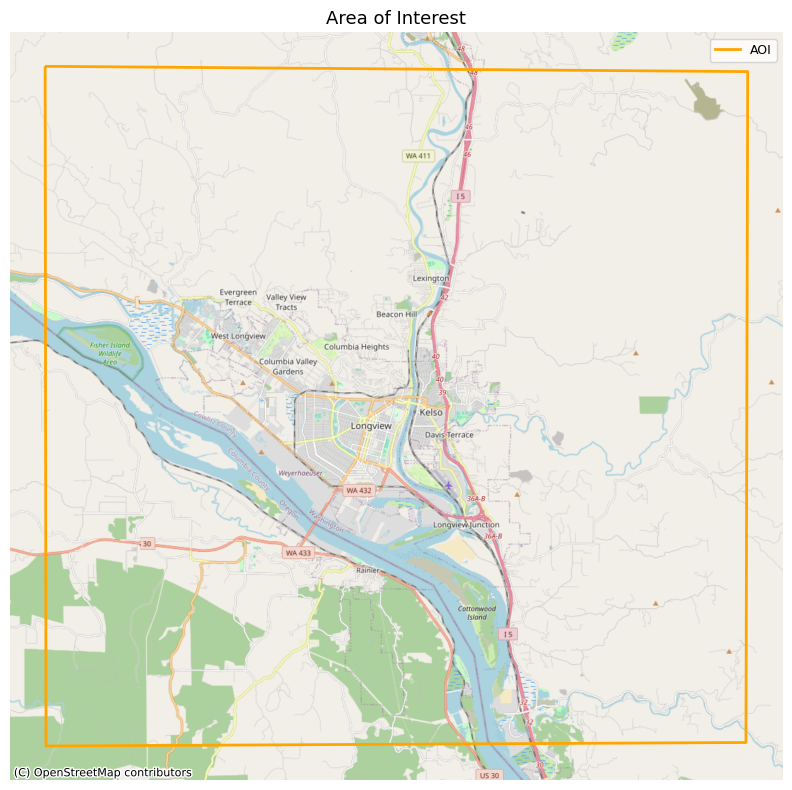


 All data files downloaded successfully.


In [37]:
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

def download_from_drive(file_id, output_path):
    """Download a file from Google Drive by file ID."""
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, output_path, quiet=False)
    if not os.path.exists(output_path):
        raise FileNotFoundError(f"Download failed for file ID: {file_id}")
    print(f"  Downloaded: {os.path.basename(output_path)}")

print("Downloading data files from Google Drive...")

AOI_FILE        = f"{DATA_DIR}/aoi.geojson"
BUILDINGS_FILE  = f"{DATA_DIR}/buildings.geojson"
WORLDPOP_FILE   = f"{DATA_DIR}/worldpop.tif"
WORLDCOVER_FILE = f"{DATA_DIR}/worldcover.tif"

download_from_drive(AOI_GDRIVE_ID,        AOI_FILE)
download_from_drive(BUILDINGS_GDRIVE_ID,  BUILDINGS_FILE)
download_from_drive(WORLDPOP_GDRIVE_ID,   WORLDPOP_FILE)
download_from_drive(WORLDCOVER_GDRIVE_ID, WORLDCOVER_FILE)

# Preview map of AOI
fig, ax = plt.subplots(figsize=(10, 8))
aoi_3857.boundary.plot(ax=ax, color="orange", linewidth=2, label="AOI")
cx.add_basemap(ax, crs=aoi_3857.crs, source=cx.providers.OpenStreetMap.Mapnik, zoom=12)
aoi_handle = mlines.Line2D([], [], color="orange", linewidth=2, label="AOI")
ax.legend(handles=[aoi_handle], loc="upper right", fontsize=9)
ax.set_title("Area of Interest", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("\n All data files downloaded successfully.")

---
## Step 5: Load AOI and Buildings

This step loads the Area of Interest (AOI) polygon and the buildings/infrastructure layer.

- The AOI defines the geographic boundary of our analysis
- The buildings layer contains infrastructure we want to assess for risk

We reproject both layers to EPSG:3857 (Web Mercator), a metric coordinate system, so we can measure distances in kilometers.

 AOI loaded — bounds (lon/lat): -123.09303361796104,46.029852766479614,-122.75165539886176,46.25866824098946
 Buildings loaded — 31,628 features


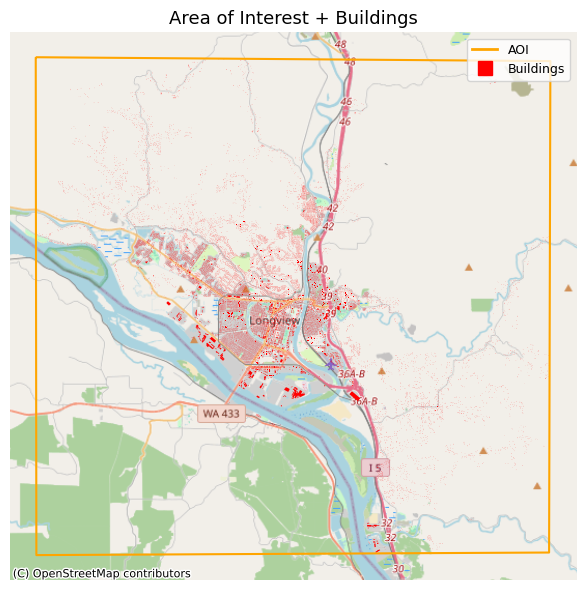

 Preview map saved.


In [36]:
# Load AOI
aoi = gpd.read_file(AOI_FILE)
if len(aoi) > 1:
    aoi = aoi.dissolve()  # Merge into single polygon if multiple features
aoi_wgs84  = aoi.to_crs("EPSG:4326")   # WGS84 for bbox + FIRMS request
aoi_3857   = aoi.to_crs("EPSG:3857")   # Metric for buffering

minx, miny, maxx, maxy = aoi_wgs84.total_bounds
bbox_str = f"{minx},{miny},{maxx},{maxy}"

# Load buildings
buildings = gpd.read_file(BUILDINGS_FILE)
buildings = buildings.to_crs("EPSG:3857")

print(f" AOI loaded — bounds (lon/lat): {bbox_str}")
print(f" Buildings loaded — {len(buildings):,} features")

# Quick preview map with basemap
fig, ax = plt.subplots(figsize=(10, 6))
aoi_3857.boundary.plot(ax=ax, color="orange", linewidth=1.5, label="AOI")
buildings.plot(ax=ax, color="red", markersize=10, alpha=1, label="Buildings")
cx.add_basemap(ax, crs=aoi_3857.crs, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title("Area of Interest + Buildings", fontsize=13)
aoi_handle = mlines.Line2D([], [], color="orange", linewidth=2, label="AOI")
bldg_handle = mlines.Line2D([], [], color="red", marker="s", linestyle="None", markersize=10, label="Buildings")
ax.legend(handles=[aoi_handle, bldg_handle], loc="upper right", fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/map_aoi_buildings.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Preview map saved.")

---
## Step 6: Fetch Active Fire Detections from NASA FIRMS

### What is FIRMS?

The **Fire Information for Resource Management System (FIRMS)** distributes near real-time 
active fire data from NASA satellites. This notebook supports two sensors — you can switch 
between them in the Configuration cell:

| Sensor | Source String | Resolution | Update Frequency |
|---|---|---|---|
| VIIRS NOAA-21 | `VIIRS_NOAA21_NRT` | 375m | Multiple times per day |
| Landsat 8/9 OLI | `LANDSAT_NRT` | 30m | Every 8 days (US/Canada only) |

Each detection includes:
- **Location** (latitude/longitude)
- **FRP** (Fire Radiative Power) — a measure of fire intensity in megawatts *(VIIRS only)*
- **Confidence** — how confident the algorithm is that this is a real fire
    - `High` or `H` — high confidence detection
    - `Medium`, `Nominal`, or `M` — moderate confidence detection
    - `Low` or `L` — low confidence detection
- **Acquisition time** — when the satellite passed over

> **Which sensor should I use?** VIIRS is best for active incident monitoring updating
multiple times daily. Landsat provides much finer detail (30m vs 375m) but only passes over 
every 8 days, so it's better suited for post-event mapping or slower-moving situations.

> **Getting your own FIRMS API key:** Register for free at 
[firms.modaps.eosdis.nasa.gov](https://firms.modaps.eosdis.nasa.gov/api/area/). 
You'll receive a key by email within minutes.

Requesting FIRMS data...
  Source : LANDSAT_NRT
  Window : last 3 day(s)
  AOI    : -123.09303361796104,46.029852766479614,-122.75165539886176,46.25866824098946

 2 FIRMS detections found in AOI
   Date range : 2026-04-26 → 2026-04-26


,acq_date,acq_time,confidence,latitude,longitude
0,2026-04-26,1855,M,46.199973,-122.865916
1,2026-04-26,1855,L,46.246814,-122.776682


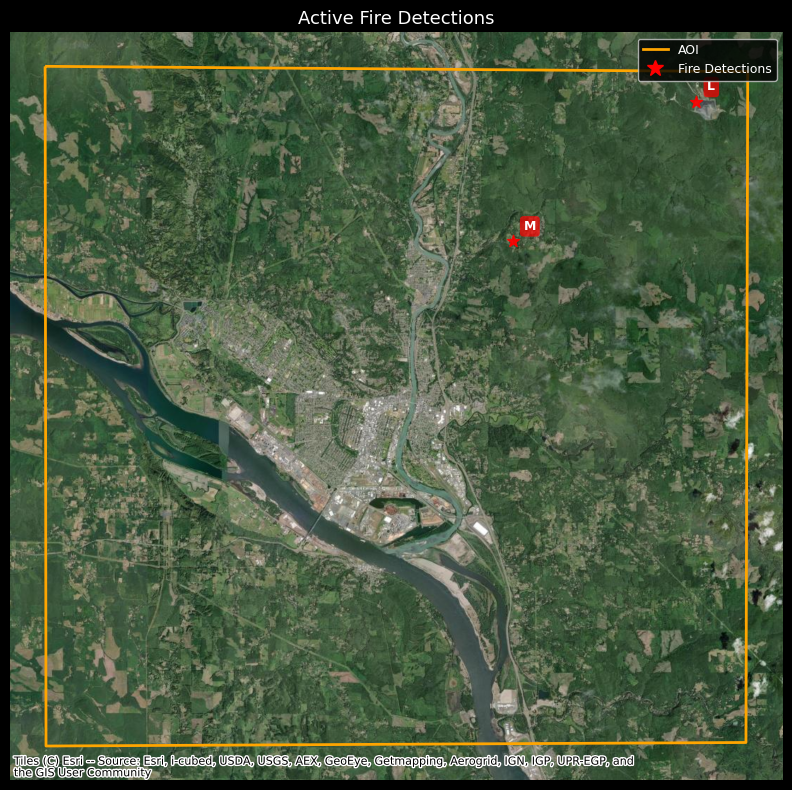

In [40]:
url = (
    f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
    f"{FIRMS_KEY}/{FIRMS_SOURCE}/{bbox_str}/{DAY_RANGE}"
)
print(f"Requesting FIRMS data...")
print(f"  Source : {FIRMS_SOURCE}")
print(f"  Window : last {DAY_RANGE} day(s)")
print(f"  AOI    : {bbox_str}\n")

r = requests.get(url)
r.raise_for_status()
df = pd.read_csv(io.StringIO(r.text))

if df.empty:
    print("  No FIRMS detections found in AOI over the selected time window.")
    print("    Try increasing DAY_RANGE in the configuration cell, or check that fires are active in this area.")
    gdf_fires = gpd.GeoDataFrame(columns=["geometry","acq_date","acq_time","frp","confidence"], crs="EPSG:4326")
else:
    gdf_fires = gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df["longitude"], df["latitude"])],
        crs="EPSG:4326",
    )
    # Clip to AOI polygon
    gdf_fires = gpd.clip(gdf_fires, aoi_wgs84)

    # Filter by confidence
    # conf_map = {"low": 0, "nominal": 1, "high": 2}
    # if "confidence" in gdf_fires.columns:
    #     gdf_fires = gdf_fires[gdf_fires["confidence"].str.lower().map(conf_map).fillna(0) >= conf_map[MIN_CONFIDENCE]]
    
    # Filter by confidence — handles both VIIRS (low/nominal/high) and Landsat (L/M/H)
if "confidence" in gdf_fires.columns:
    viirs_map   = {"low": 0, "nominal": 1, "high": 2}
    landsat_map = {"l": 0, "m": 1, "h": 2}
    min_viirs   = {"low": 0, "nominal": 1, "high": 2}

    def normalize_confidence(val):
        v = str(val).lower()
        if v in viirs_map:
            return viirs_map[v]
        if v in landsat_map:
            return landsat_map[v]
        return 0

    gdf_fires["conf_numeric"] = gdf_fires["confidence"].apply(normalize_confidence)
    gdf_fires = gdf_fires[gdf_fires["conf_numeric"] >= min_viirs[MIN_CONFIDENCE]]

    print(f" {len(gdf_fires):,} FIRMS detections found in AOI")
    print(f"   Date range : {gdf_fires['acq_date'].min()} → {gdf_fires['acq_date'].max()}")
    if "frp" in gdf_fires.columns:
        print(f"   FRP range  : {gdf_fires['frp'].min():.1f} – {gdf_fires['frp'].max():.1f} MW")
    # display(gdf_fires[["acq_date","acq_time","frp","confidence","latitude","longitude"]].head(10))
    # Display available columns (handles both VIIRS and Landsat attribute differences)
    display_cols = [c for c in ["acq_date","acq_time","frp","confidence","latitude","longitude"] if c in gdf_fires.columns]
    display(gdf_fires[display_cols].head(10))

    # Preview map of fire detections
fig, ax = plt.subplots(figsize=(10, 8))
aoi_3857.boundary.plot(ax=ax, color="orange", linewidth=2)
fires_preview = gdf_fires.to_crs("EPSG:3857")
fires_preview.plot(ax=ax, color="red", markersize=80, marker="*", alpha=0.9, zorder=5)
for _, row in fires_preview.iterrows():
    ax.annotate(
        text=str(row["confidence"]).upper(),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(8, 8),
        textcoords="offset points",
        color="white",
        fontsize=9,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.7, edgecolor="none")
    )
cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.Esri.WorldImagery, zoom=12)

# Legend
aoi_handle = mlines.Line2D([], [], color="orange", linewidth=2, label="AOI")
fire_handle = mlines.Line2D([], [], color="red", marker="*", linestyle="None", markersize=12, label="Fire Detections")
ax.legend(handles=[aoi_handle, fire_handle], loc="upper right", fontsize=9, 
          facecolor="black", labelcolor="white")
ax.set_title("Active Fire Detections", fontsize=13, color="white")
fig.patch.set_facecolor("black")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/map_fire_detections.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 7: Create Buffer Risk Zones

We create three concentric buffer rings around fire detections:

| Ring | Distance | Interpretation |
|---|---|---|
| Zone 1 | 0 – 2 km | Immediate threat — evacuation likely required |
| Zone 2 | 2 – 5 km | High risk — prepare for rapid evacuation |
| Zone 3 | 5 – 10 km | Extended risk — monitor closely |

Buffers from multiple detections are dissolved into unified zones so overlapping fire clusters are treated as one continuous threat area.

In [ ]:
fires_3857 = gdf_fires.to_crs("EPSG:3857") if not gdf_fires.empty else gdf_fires

ring_colors = {2: "#d73027", 5: "#fc8d59", 10: "#fee090"}
ring_labels = {2: "Zone 1 (0–2 km)", 5: "Zone 2 (2–5 km)", 10: "Zone 3 (5–10 km)"}
buffer_gdfs = {}

if not fires_3857.empty:
    for km in BUFFER_RINGS_KM:
        buffered = fires_3857.copy()
        buffered["geometry"] = fires_3857.buffer(km * 1000)
        dissolved = buffered.dissolve()
        dissolved["ring_km"] = km
        dissolved["label"]   = ring_labels[km]
        buffer_gdfs[km] = dissolved
        print(f"   {ring_labels[km]} buffer created")

    # Map: AOI + fires + buffer rings
    fig, ax = plt.subplots(figsize=(10, 8))
    aoi_3857.boundary.plot(ax=ax, color="black", linewidth=1.5)
    for km in reversed(BUFFER_RINGS_KM):
        buffer_gdfs[km].plot(ax=ax, color=ring_colors[km], alpha=0.4, label=ring_labels[km])
    fires_3857.plot(ax=ax, color="red", markersize=15, zorder=5, label="Fire detections")
    buildings.plot(ax=ax, color="steelblue", markersize=1, alpha=0.4, label="Buildings")
    ax.set_title(f"{INCIDENT_NAME} — Fire Detections & Risk Zones", fontsize=13)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/map_risk_zones.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n Risk zone map saved.")
else:
    print("  No fire detections — skipping buffer creation.")

---
## Step 8: Infrastructure at Risk

We intersect each buffer ring with the buildings layer to identify how many structures fall within each risk zone.

This is a spatial join — we're asking: which buildings overlap with each buffer ring?

In [ ]:
infra_results = []
buildings_at_risk_all = []

if buffer_gdfs:
    prev_buffer = None
    for km in BUFFER_RINGS_KM:
        ring_geom = buffer_gdfs[km].copy()

        # Subtract inner ring to get the donut zone
        if prev_buffer is not None:
            ring_geom["geometry"] = ring_geom.difference(prev_buffer.unary_union)

        at_risk = gpd.sjoin(buildings, ring_geom[["geometry","ring_km","label"]], how="inner", predicate="intersects")
        at_risk = at_risk.reset_index().drop_duplicates(subset=["index"])
        at_risk["risk_zone"] = ring_labels[km]
        buildings_at_risk_all.append(at_risk)

        infra_results.append({"Zone": ring_labels[km], "Buildings at Risk": len(at_risk)})
        print(f"  {ring_labels[km]}: {len(at_risk):,} buildings")
        prev_buffer = buffer_gdfs[km]

    infra_df = pd.DataFrame(infra_results)
    print("\n Infrastructure Summary:")
    display(infra_df)

    # Combine all at-risk buildings
    if buildings_at_risk_all:
        all_at_risk_gdf = gpd.GeoDataFrame(pd.concat(buildings_at_risk_all, ignore_index=True), crs="EPSG:3857")
else:
    print("  No buffer zones — skipping infrastructure analysis.")
    infra_df = pd.DataFrame(columns=["Zone", "Buildings at Risk"])

---
## Step 9: Population Exposure

### What is WorldPop?

WorldPop provides gridded population estimates at approximately 100m resolution. Each pixel in the raster represents an estimated number of people living in that grid cell.

We calculate zonal statistics — summing up all the population pixels that fall within each buffer ring — to estimate how many people are exposed.

> Getting your own WorldPop data: Download country-level population rasters from [worldpop.org/datacatalog](https://www.worldpop.org/datacatalog/). Select your country, choose "Population Counts", and download the most recent year. Then clip to your AOI in QGIS.

In [ ]:
pop_results = []

if buffer_gdfs and os.path.exists(WORLDPOP_FILE):
    with rasterio.open(WORLDPOP_FILE) as src:
        pop_crs = src.crs

        prev_buffer = None
        for km in BUFFER_RINGS_KM:
            ring_geom = buffer_gdfs[km].to_crs(pop_crs).copy()

            # Subtract inner ring for donut zones
            if prev_buffer is not None:
                inner = prev_buffer.to_crs(pop_crs)
                ring_geom["geometry"] = ring_geom.difference(inner.unary_union)

            shapes = [geom for geom in ring_geom.geometry if geom is not None and not geom.is_empty]
            if not shapes:
                pop_results.append({"Zone": ring_labels[km], "Estimated Population": 0})
                prev_buffer = buffer_gdfs[km]
                continue

            out_image, _ = rio_mask(src, shapes, crop=True, nodata=np.nan)
            data = out_image[0]
            pop_sum = int(np.nansum(data[data > 0]))
            pop_results.append({"Zone": ring_labels[km], "Estimated Population": pop_sum})
            print(f"  {ring_labels[km]}: ~{pop_sum:,} people")
            prev_buffer = buffer_gdfs[km]

    pop_df = pd.DataFrame(pop_results)
    print("\n Population Exposure Summary:")
    display(pop_df)
else:
    print("  WorldPop file not found or no fire detections — skipping population analysis.")
    pop_df = pd.DataFrame(columns=["Zone", "Estimated Population"])

---
## Step 10: Land Cover Analysis

### What is ESA WorldCover?

ESA WorldCover is a global land cover map at 10m resolution, produced by the European Space Agency. It classifies the land surface into 11 categories.

For wildfire analysis, land cover tells us about fuel types — forests and shrublands burn very differently from cropland or urban areas.

| Class | Code | Fire Relevance |
|---|---|---|
| Tree Cover | 10 | High fuel load — dense canopy fires |
| Shrubland | 20 | High spread risk — fast-moving surface fires |
| Grassland | 30 | Very fast spread in dry conditions |
| Cropland | 40 | Moderate — depends on crop type and season |
| Built-up | 50 | Urban interface — structural fire risk |
| Bare/Sparse | 60 | Low fuel — natural firebreak |
| Water | 80 | No fuel — natural firebreak |

> Getting your own WorldCover data: Download tiles from [esa-worldcover.org](https://esa-worldcover.org/en/data). Use the viewer to find which tiles cover your AOI, download, and mosaic/clip in QGIS if needed.

In [ ]:
WORLDCOVER_CLASSES = {
    10: "Tree Cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / Sparse Vegetation",
    70: "Snow and Ice",
    80: "Permanent Water",
    90: "Herbaceous Wetland",
    95: "Mangroves",
    100: "Moss and Lichen"
}

HIGH_RISK_CLASSES = {10, 20, 30}  # Tree cover, shrubland, grassland

lc_results = []

if buffer_gdfs and os.path.exists(WORLDCOVER_FILE):
    with rasterio.open(WORLDCOVER_FILE) as src:
        lc_crs = src.crs

        for km in BUFFER_RINGS_KM:
            ring_geom = buffer_gdfs[km].to_crs(lc_crs)
            shapes = [geom for geom in ring_geom.geometry if geom is not None and not geom.is_empty]
            if not shapes:
                continue

            out_image, _ = rio_mask(src, shapes, crop=True, nodata=0)
            data = out_image[0]
            unique, counts = np.unique(data[data > 0], return_counts=True)
            total = counts.sum()

            high_risk_pct = sum(counts[i] for i, u in enumerate(unique) if u in HIGH_RISK_CLASSES) / total * 100 if total > 0 else 0
            dominant_class = WORLDCOVER_CLASSES.get(int(unique[counts.argmax()]), "Unknown") if len(unique) > 0 else "Unknown"

            class_breakdown = ", ".join(
                f"{WORLDCOVER_CLASSES.get(int(u), str(u))}: {c/total*100:.0f}%"
                for u, c in sorted(zip(unique, counts), key=lambda x: -x[1])[:4]
            ) if total > 0 else "No data"

            lc_results.append({
                "Zone": ring_labels[km],
                "Dominant Cover": dominant_class,
                "High-Risk Fuel %": f"{high_risk_pct:.0f}%",
                "Breakdown": class_breakdown
            })
            print(f"  {ring_labels[km]}: dominant = {dominant_class}, high-risk fuel = {high_risk_pct:.0f}%")

    lc_df = pd.DataFrame(lc_results)
    print("\nLand Cover Summary:")
    display(lc_df)
else:
    print("WorldCover file not found or no fire detections — skipping land cover analysis.")
    lc_df = pd.DataFrame(columns=["Zone", "Dominant Cover", "High-Risk Fuel %", "Breakdown"])

---
## Step 11: Generate Outputs

We now generate three output products:

1. PDF Briefing — a one-page summary with maps, risk zone tables, and key findings
2. GeoJSON Package — a ZIP file with all spatial layers ready to load into QGIS
3. Markdown Summary — printed inline in the notebook

### Loading the GeoJSON package in QGIS
1. Unzip the downloaded package
2. Open QGIS → Layer → Add Layer → Add Vector Layer
3. Browse to the unzipped folder and add each `.geojson` file
4. Style layers by `risk_zone` field for a colour-coded map

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
safe_name = INCIDENT_NAME.replace(" ", "_")

# ── 1. Save GeoJSON layers ──────────────────────────────────────────────────
geojson_dir = f"{OUTPUT_DIR}/geojson"
os.makedirs(geojson_dir, exist_ok=True)

if not gdf_fires.empty:
    gdf_fires.to_crs("EPSG:4326").to_file(f"{geojson_dir}/fire_detections.geojson", driver="GeoJSON")
    print(" Saved: fire_detections.geojson")

if buffer_gdfs:
    all_rings = gpd.GeoDataFrame(
        pd.concat([buffer_gdfs[km] for km in BUFFER_RINGS_KM], ignore_index=True),
        crs="EPSG:3857"
    )
    all_rings.to_crs("EPSG:4326").to_file(f"{geojson_dir}/risk_zones.geojson", driver="GeoJSON")
    print(" Saved: risk_zones.geojson")

if 'all_at_risk_gdf' in dir() and not all_at_risk_gdf.empty:
    all_at_risk_gdf.to_crs("EPSG:4326").to_file(f"{geojson_dir}/buildings_at_risk.geojson", driver="GeoJSON")
    print(" Saved: buildings_at_risk.geojson")

# ZIP the GeoJSON folder
zip_path = f"{OUTPUT_DIR}/{safe_name}_{timestamp}_QGIS_package.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for fname in os.listdir(geojson_dir):
        zf.write(os.path.join(geojson_dir, fname), fname)
print(f" GeoJSON package zipped: {os.path.basename(zip_path)}")

# ── 2. Markdown Summary ────────────────────────────────────────────────────
total_pop = pop_df["Estimated Population"].sum() if not pop_df.empty else "N/A"
total_bldg = infra_df["Buildings at Risk"].sum() if not infra_df.empty else "N/A"
n_detections = len(gdf_fires)

summary_md = f"""
---
##  Incident Summary — {INCIDENT_NAME}
**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M UTC")}  
**Data source:** NASA FIRMS VIIRS NOAA-21 | Last {DAY_RANGE} day(s)

###  Fire Detections
- **{n_detections:,}** active fire detections in AOI

###  Infrastructure at Risk
| Zone | Buildings |
|---|---|
"""
for _, row in infra_df.iterrows():
    summary_md += f"| {row['Zone']} | {row['Buildings at Risk']:,} |\n"
summary_md += f"| **Total** | **{total_bldg:,}** |\n"

summary_md += f"""
###  Population Exposure
| Zone | Estimated Population |
|---|---|
"""
for _, row in pop_df.iterrows():
    summary_md += f"| {row['Zone']} | {row['Estimated Population']:,} |\n"
summary_md += f"| **Total** | **{total_pop:,}** |\n"

summary_md += f"""
###  Land Cover (Fuel Assessment)
| Zone | Dominant Cover | High-Risk Fuel % |
|---|---|---|
"""
for _, row in lc_df.iterrows():
    summary_md += f"| {row['Zone']} | {row['Dominant Cover']} | {row['High-Risk Fuel %']} |\n"

from IPython.display import Markdown
display(Markdown(summary_md))

In [ ]:
# ── 3. Generate PDF Briefing ───────────────────────────────────────────────
pdf_path = f"{OUTPUT_DIR}/{safe_name}_{timestamp}_briefing.pdf"
doc = SimpleDocTemplate(pdf_path, pagesize=letter,
                        rightMargin=0.75*inch, leftMargin=0.75*inch,
                        topMargin=0.75*inch, bottomMargin=0.75*inch)
styles = getSampleStyleSheet()
story = []

# Title
title_style = ParagraphStyle("Title", parent=styles["Title"], fontSize=18, spaceAfter=6)
sub_style   = ParagraphStyle("Sub", parent=styles["Normal"], fontSize=10, textColor=colors.gray, spaceAfter=12, alignment=TA_CENTER)
h2_style    = ParagraphStyle("H2", parent=styles["Heading2"], fontSize=13, spaceBefore=14, spaceAfter=6)
body_style  = ParagraphStyle("Body", parent=styles["Normal"], fontSize=10, spaceAfter=6)

story.append(Paragraph(f"Wildfire Early Warning Briefing", title_style))
story.append(Paragraph(f"{INCIDENT_NAME}  |  {datetime.now().strftime('%Y-%m-%d %H:%M UTC')}", sub_style))
story.append(Paragraph(f"Data: NASA FIRMS VIIRS NOAA-21 | Last {DAY_RANGE} day(s) | Confidence filter: {MIN_CONFIDENCE}", sub_style))

# Map image
map_img_path = f"{OUTPUT_DIR}/map_risk_zones.png"
if os.path.exists(map_img_path):
    story.append(Paragraph("Risk Zone Map", h2_style))
    story.append(RLImage(map_img_path, width=6*inch, height=4.5*inch))
    story.append(Spacer(1, 0.2*inch))

# Key findings
story.append(Paragraph("Key Findings", h2_style))
story.append(Paragraph(f"<b>{n_detections:,}</b> active fire detections identified in the AOI over the last {DAY_RANGE} day(s).", body_style))
story.append(Paragraph(f"<b>{total_bldg:,}</b> total buildings identified within risk zones.", body_style))
story.append(Paragraph(f"<b>{total_pop:,}</b> people estimated within risk zones (WorldPop).", body_style))

# Infrastructure table
story.append(Paragraph("Infrastructure at Risk", h2_style))
if not infra_df.empty:
    t_data = [["Zone", "Buildings at Risk"]] + infra_df.values.tolist()
    t = Table(t_data, colWidths=[3.5*inch, 2.5*inch])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#c0392b")),
        ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
        ("FONTNAME",   (0,0), (-1,0), "Helvetica-Bold"),
        ("ROWBACKGROUNDS", (0,1), (-1,-1), [colors.whitesmoke, colors.white]),
        ("GRID",       (0,0), (-1,-1), 0.5, colors.lightgrey),
        ("FONTSIZE",   (0,0), (-1,-1), 10),
        ("ALIGN",      (1,0), (1,-1), "CENTER"),
    ]))
    story.append(t)

# Population table
story.append(Paragraph("Population Exposure", h2_style))
if not pop_df.empty:
    t_data = [["Zone", "Estimated Population"]] + pop_df.values.tolist()
    t = Table(t_data, colWidths=[3.5*inch, 2.5*inch])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#e67e22")),
        ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
        ("FONTNAME",   (0,0), (-1,0), "Helvetica-Bold"),
        ("ROWBACKGROUNDS", (0,1), (-1,-1), [colors.whitesmoke, colors.white]),
        ("GRID",       (0,0), (-1,-1), 0.5, colors.lightgrey),
        ("FONTSIZE",   (0,0), (-1,-1), 10),
        ("ALIGN",      (1,0), (1,-1), "CENTER"),
    ]))
    story.append(t)

# Land cover table
story.append(Paragraph("Land Cover & Fuel Assessment", h2_style))
if not lc_df.empty:
    t_data = [["Zone", "Dominant Cover", "High-Risk Fuel %"]] + lc_df[["Zone","Dominant Cover","High-Risk Fuel %"]].values.tolist()
    t = Table(t_data, colWidths=[2.5*inch, 2.5*inch, 1.5*inch])
    t.setStyle(TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#27ae60")),
        ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
        ("FONTNAME",   (0,0), (-1,0), "Helvetica-Bold"),
        ("ROWBACKGROUNDS", (0,1), (-1,-1), [colors.whitesmoke, colors.white]),
        ("GRID",       (0,0), (-1,-1), 0.5, colors.lightgrey),
        ("FONTSIZE",   (0,0), (-1,-1), 10),
        ("ALIGN",      (2,0), (2,-1), "CENTER"),
    ]))
    story.append(t)

# Footer note
story.append(Spacer(1, 0.3*inch))
footer_style = ParagraphStyle("Footer", parent=styles["Normal"], fontSize=8, textColor=colors.gray)
story.append(Paragraph("Generated by NASA Disasters Wildfire Early Warning Module. Fire detections from NASA FIRMS VIIRS NOAA-21 NRT. Population data from WorldPop. Land cover from ESA WorldCover.", footer_style))

doc.build(story)
print(f" PDF briefing saved: {os.path.basename(pdf_path)}")
print(f"\n All outputs saved to: {OUTPUT_DIR}")
print(f"   - {os.path.basename(pdf_path)}")
print(f"   - {os.path.basename(zip_path)}")

---
## Step 12: Download Your Outputs

Run this cell to download the PDF briefing and GeoJSON package directly to your computer.

In [ ]:
from google.colab import files

print("Downloading outputs...")
files.download(pdf_path)
files.download(zip_path)
print(" Downloads initiated. Check your browser's download folder.")

---
## Next Steps

Now that you've run this pipeline for the demo AOI, here's how to adapt it for your own incident:

1. **Define your own AOI** — draw a polygon in QGIS or [geojson.io](https://geojson.io) and export as GeoJSON
2. **Get your own FIRMS key** — free registration at [firms.modaps.eosdis.nasa.gov](https://firms.modaps.eosdis.nasa.gov/api/area/)
3. **Download WorldPop** for your country from [worldpop.org](https://www.worldpop.org/datacatalog/)
4. **Download ESA WorldCover** tiles for your region from [esa-worldcover.org](https://esa-worldcover.org/en/data)
5. **Clip your rasters to your AOI** in QGIS (**Raster → Extraction → Clip Raster by Mask Layer**)
6. **Upload all files to Google Drive**, get their file IDs, and update the Configuration cell
7. **Run the notebook** — all outputs will be generated automatically

---
*Module developed by the NASA Disasters Program | [NASA Lifelines](https://nasalifelines.org)*